<a href="https://colab.research.google.com/github/ImSayvi/CV/blob/main/21032026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [18]:
observations = 10000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))
inputs = (inputs - np.mean(inputs, axis=0)) / np.std(inputs, axis=0)
# normalizacja; potem trzeba odnormalzować
print(inputs.shape)

(10000, 2)


In [19]:
noise = np.random.uniform(low=-1,high=1, size=(observations,1))
targets = 4*xs - 44*zs + 6 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(10000, 1)


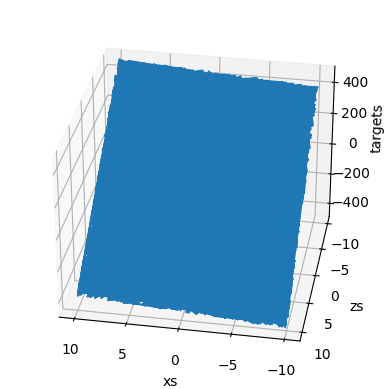

In [20]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('targets')
ax.view_init(azim=100)
plt.show()


In [21]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights,biases)

[[ 0.00619343]
 [-0.09052426]] [-0.0198732]


In [22]:
targets = targets.reshape(observations,1)
eta = 0.01

for i in range (5000):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)
  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

32724.865513733148
32074.58789264052
31437.232943847157
30812.54384291966
30200.268869897605
29600.16130783322
29011.979343347968
28435.48596916583
27870.448888584066
27316.64042184286
26773.83741435625
26241.821146767154
25720.377246790365
25209.295602807902
24708.370279181945
24217.399433251117
23736.185233976732
23264.533782206203
22802.255032521374
22349.16271664041
21905.074268342214
21469.810749883218
21043.19677987685
20625.060462606518
20215.23331874379
19813.550217443637
19419.849309789486
19033.97196356128
18655.762699300092
18285.069127643666
17921.741887907585
17565.634587887256
17216.603744856464
16874.508727738765
16539.211700428335
16210.577566237433
15888.47391344811
15572.770961946226
15263.34151091619
14960.06088757543
14662.806896927807
14371.459772515887
14085.90212815203
13806.018910608962
13531.697353250718
13262.826930585248
12999.299313720423
12741.008326705372
12487.849903739694
12239.72204723316
11996.524786699101
11758.16013846483
11524.532066182928
11295.546

In [17]:
print(weights,biases)

[[ 0.81175998]
 [-2.72870114]] [4.94597387]


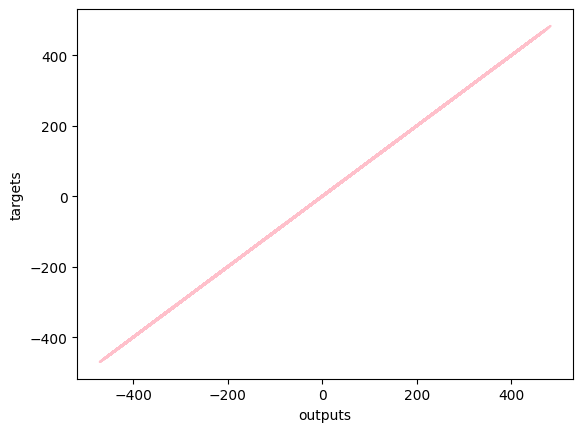

In [23]:
plt.plot(outputs, targets, color='pink')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()

In [24]:
means = np.mean(np.column_stack((xs, zs)), axis=0)
stds = np.std(np.column_stack((xs, zs)), axis=0)

w1_norm = weights[0][0]
w2_norm = weights[1][0]

w1 = w1_norm / stds[0]
w2 = w2_norm / stds[1]

b = biases[0] - (w1_norm * means[0] / stds[0]) - (w2_norm * means[1] / stds[1])

#odnormalizowywuje xd
print(w1, w2, b)

Oryginalne wagi:
3.9981387322715514 -43.99912289640185 6.008352859370811
